## Sex Hormones

Sex hormones also affect how the body stores adiposity. Hormonal imbalance can cause varying effects on the human body. For example, female with polycystic ovarian syndrome (PCOS) have higher testosterone levels. They are more likely to be overweight compared to female with normal hormone balance. 

This analysis will evaluate how the sex hormones affect the BMI.

NHANES data includes the following sex hormones and their ranges as shown in their lab documentation unless otherwise indicated:

* **17-hydroxyprogesterone (17-OHP) (ng/dL)**: a steroid hormone produced by the adrenal glands and gonads, acting as a precursor to cortisol.
    * Males: 41 – 183 ng/dL
    * Females:
        * Follicular: 45 – 1185 ng/dL
        * Luteal: 42 – 450 ng/dL
        * Postmenopausal: 18 – 48 ng/dL
        
* **Androstenedione (ng/dL)**: a weak androgenic steroid hormone produced by the adrenal glands and gonads, acting as a direct precursor to testosterone and estrogen.
    * Males: 75 - 205 ng/dL
    * Females: 85 - 275 ng/dL

* **Progesterone (ng/dL)**
    * Males: 13 - 97 ng/dL
    * Females:
        * Follicular: 15 – 70
        * Luteal: 200 – 2500
        * Gestation:
            * First trimester: 1025 – 4400
            * Second trimester: 1950 – 8250
            * Third trimester: 6500 – 22,900

* **Testosterone (ng/dL)**
    * Males: 280 – 1100
    * Females: 15 – 70
        * Postemenopausal: 8 – 35

* **Anti-müllerian hormone (AMH)**: in the developing fetus, works to determine the sex of the fetus. In adult females, it can assess ovarian reserve. AMH ranges vary by age (the following values are provided by Cleveland Clinic and represent lower end of the spectrum for the ages):
    * 25 years old: 3.0 ng/mL.
    * 30 years old: 2.5 ng/mL.
    * 35 years old: 1.5 ng/ mL.
    * 40 years old: 1 ng/mL.
    * 45 years old: 0.5 ng/mL.

* **Estradiol (E2) (pg/mL)**: the primary and most potent form of estrogen in the human body
    * Adult males: 10-50 pg/mL
    * Adult females:
        * Early follicular phase: 20 - 150
        * Late follicular phase: 40-350 pg/mL
        * Midcycle peak: 150-750 pg/mL
        * Luteal phase: 30-450 pg/mL
        * Postmenopause: ≤ 20 pg/mL

* **Esterone (E1) (ng/dL)**: the primary form of estrogen that your body makes after menopause.
    * Males: 1.5 – 6.5
    * Females:
        * Early follicular phase: 1.5 – 15
        * Late follicular phase: 10 - 25
        * Luteal phase: 1.5 - 20
        * Postmenopausal: 1.5 - 5.5

* **Estriol (E3)**: primary form of estrogen during pregnancy

* **Esterone sulfate (pg/mL)**
    * Male: 230 - 2200
    * Female:
        * Follicular: 300 - 2600
        * Luteal: 100 - 3200
        * Postmenopausal: 100 - 1300

* **Dehydroepiandrosterone sulfate (DHEAS) (mcg/dL)**
    * Male:
        * 19 - 30 y/o: 125 - 619
        * 31 - 50 y/o: 59 - 452
        * 51 - 60 y/o: 20 - 413
        * 61 - 83 y/o: 10 - 285
    * Female:
        * 19 - 30 y/o: 29 - 781
        * 31 - 50 y/o: 12 - 379
        * Postemenopausal: 30 - 260

* **Follicle Stimulating Hormone (FSH)** from medline.gov
    * Adult male: 1.5 - 12.4 mIU/mL
    * Adult female: 4.7 - 21.5 mIU/mL
        * Postmenopausal: 25.8 - 134.8 mIU/mL

* **Luteinizing Hormong (LH)** from medline.gov
    * Adult male: 1.8 - 8.6 IU/L
    * Adult female: 5 - 25 IU/L
        * Postmenopausal: 7.7 - 58.5 IU/L

* **Sex Hormone Binding Globulin (SHBG) nmol/L** from LabCorp
    * Male:
        * 20-49 y/o: 16.5 - 55.9 
        * >49 y/o: 19.3 - 76.4
    * Female:
        * 20-49 y/o: 24.6 - 122
        * >49 y/o: 17.3 - 125

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import os
import statsmodels.api as sm
import scipy.stats as stats
from math import erf, sqrt
from math import atanh, sqrt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df = pd.read_csv('sex_hormones.csv')

In [3]:
df = df_d.merge(df_a, on='participant_id').merge(df, on='participant_id')

In [4]:
df.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,weight_comment,recumbent_length_cm,...,estrone_sulfate_comment_code,follicle_stimulating_hormone_miu_ml,fsh_comment_code,luteinizing_hormone_miu_ml,luteinizing_hormone_comment_code,progesterone_ng_dl,progesterone_nmol_l,progesterone_comment_code,shbg_nmol_l,shbg_comment_code
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,NaN,NaN,...,NaN,7.15,0.0,4.55,0.0,1.500,0.0477,0.0,22.54,0.0
1,109270.0,2.0,11.0,4.0,NaN,NaN,1.88,75.3,NaN,NaN,...,0.0,4.87,0.0,3.64,0.0,0.608,0.0193,1.0,23.68,0.0
2,109271.0,1.0,49.0,3.0,2.0,3.0,NaN,98.8,NaN,NaN,...,0.0,8.30,0.0,18.86,0.0,8.770,0.2790,0.0,42.91,0.0
3,109273.0,1.0,36.0,3.0,4.0,3.0,0.83,74.3,NaN,NaN,...,0.0,3.33,0.0,4.22,0.0,16.000,0.5090,0.0,59.72,0.0
4,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,NaN,NaN,...,0.0,5.14,0.0,9.47,0.0,4.110,0.1310,0.0,62.92,0.0


In [5]:
df.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'weight_comment', 'recumbent_length_cm', 'standing_height',
       'standing_height_comment', 'bmi', 'bmi_category_child', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'Unnamed: 0', '17α_hydroxyprogesterone_ng_dl',
       '17α_hydroxyprogesterone_nmol_l',
       '17α_hydroxyprogesterone_comment_code', 'androstenedione_ng_dl',
       'androstenedione_nmol_l', 'androstenedione_comment_code',
       'anti_mullerian_hormone_ng_ml', 'anti_mullerian_hormone_pmol_l',
       'anti_mullerian_hormone_comment_code', 'estradiol_pg_ml',
       'estradiol_pmol_l', 'estradiol_comment_code', 'estrone_ng_dl',
       'estrone_pmol_l', 'estrone_comment_code', 'estrone_sulfate_pg_ml',
       'estrone_sulfate_pmol_l', 'estrone_sulfate_comment_code',
       'follicle_stimulating_hormone_miu_ml', 'fsh_comment_c

In [6]:
df = df.drop(['education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'weight_comment', 'recumbent_length_cm', 'standing_height',
       'standing_height_comment','bmi_category_child', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'Unnamed: 0', '17α_hydroxyprogesterone_nmol_l','17α_hydroxyprogesterone_comment_code',
       'androstenedione_nmol_l', 'androstenedione_comment_code', 'anti_mullerian_hormone_pmol_l',
       'anti_mullerian_hormone_comment_code', 'estradiol_pmol_l', 'estradiol_comment_code', 'estrone_pmol_l', 'estrone_comment_code', 'estrone_sulfate_pmol_l', 'estrone_sulfate_comment_code','fsh_comment_code','luteinizing_hormone_comment_code','progesterone_nmol_l',
       'progesterone_comment_code','shbg_comment_code'], axis=1)

In [7]:
df.head()

,participant_id,gender,age_year,race,bmi,17α_hydroxyprogesterone_ng_dl,androstenedione_ng_dl,anti_mullerian_hormone_ng_ml,estradiol_pg_ml,estrone_ng_dl,estrone_sulfate_pg_ml,follicle_stimulating_hormone_miu_ml,luteinizing_hormone_miu_ml,progesterone_ng_dl,shbg_nmol_l
0,109266.0,2.0,29.0,6.0,37.8,27.1,93.1,1.65,35.5,4.53,NaN,7.15,4.55,1.500,22.54
1,109270.0,2.0,11.0,4.0,30.9,NaN,52.3,1.93,31.3,2.65,711.0,4.87,3.64,0.608,23.68
2,109271.0,1.0,49.0,3.0,29.7,114.0,166.0,NaN,69.6,14.90,273.0,8.30,18.86,8.770,42.91
3,109273.0,1.0,36.0,3.0,21.9,164.0,91.7,NaN,23.4,2.58,267.0,3.33,4.22,16.000,59.72
4,109274.0,1.0,68.0,7.0,30.2,74.6,46.8,NaN,36.3,4.31,303.0,5.14,9.47,4.110,62.92


In [8]:
df.describe()

,participant_id,gender,age_year,race,bmi,17α_hydroxyprogesterone_ng_dl,androstenedione_ng_dl,anti_mullerian_hormone_ng_ml,estradiol_pg_ml,estrone_ng_dl,estrone_sulfate_pg_ml,follicle_stimulating_hormone_miu_ml,luteinizing_hormone_miu_ml,progesterone_ng_dl,shbg_nmol_l
count,9445.000000,9445.000000,9445.000000,9445.000000,9411.000000,8153.000000,9435.000000,4635.000000,9104.000000,9086.000000,8922.000000,9029.000000,9125.000000,9387.000000,9087.000000
mean,117082.408258,1.511276,40.974801,3.433986,28.091574,65.945709,74.624907,1.426751,69.663630,5.204874,779.861483,18.634112,12.450835,100.013570,51.998016
std,4491.820218,0.499899,22.814214,1.612376,7.988300,63.685288,51.857873,2.096566,542.271437,18.716788,1224.052898,27.643886,14.476501,573.839339,43.661451
min,109266.000000,1.000000,6.000000,1.000000,12.600000,0.290000,0.580000,0.020000,1.220000,0.091900,1.440000,0.210000,0.070000,0.608000,0.830000
25%,113188.000000,1.000000,19.000000,3.000000,22.600000,24.000000,40.800000,0.020000,8.080000,2.110000,210.000000,3.220000,3.800000,2.530000,27.460000
50%,117054.000000,2.000000,41.000000,3.000000,27.100000,48.700000,63.600000,0.370000,22.400000,3.370000,475.500000,5.740000,6.630000,4.500000,41.100000
75%,121001.000000,2.000000,61.000000,4.000000,32.400000,85.800000,95.800000,2.260000,37.700000,5.180000,910.000000,17.430000,14.980000,8.515000,63.020000
max,124822.000000,2.000000,80.000000,7.000000,92.300000,1110.000000,649.000000,30.690000,15300.000000,497.000000,24900.000000,187.700000,150.300000,16200.000000,895.500000


In [14]:
df = df[df['age_year'] >=18]

In [15]:
df_females = df[df['gender'] == 2]
df_males = df[df['gender'] == 1]

In [16]:
df_females.describe()

,participant_id,gender,age_year,race,bmi,17α_hydroxyprogesterone_ng_dl,androstenedione_ng_dl,anti_mullerian_hormone_ng_ml,estradiol_pg_ml,estrone_ng_dl,estrone_sulfate_pg_ml,follicle_stimulating_hormone_miu_ml,luteinizing_hormone_miu_ml,progesterone_ng_dl,shbg_nmol_l
count,3753.000000,3753.0,3753.000000,3753.000000,3745.000000,3737.000000,3751.000000,3750.000000,3614.000000,3610.000000,3506.000000,3746.000000,3751.000000,3722.000000,3749.000000
mean,117071.527045,2.0,49.185452,3.432454,30.504486,52.701282,82.839203,1.104867,132.002147,7.938887,982.549746,36.214640,21.781712,215.265639,63.637407
std,4466.977586,0.0,18.125502,1.556259,8.312792,73.438048,59.354508,2.009731,855.749462,29.329897,1712.792597,35.006852,17.769300,881.117410,56.781679
min,109266.000000,2.0,18.000000,1.000000,14.200000,0.290000,0.580000,0.020000,1.220000,0.091900,1.440000,0.210000,0.070000,0.608000,2.050000
25%,113254.000000,2.0,34.000000,3.000000,24.500000,14.800000,42.000000,0.020000,5.212500,2.340000,206.000000,5.630000,6.815000,2.382500,33.600000
50%,117028.000000,2.0,50.000000,3.000000,29.100000,25.300000,66.500000,0.020000,17.500000,3.935000,450.500000,26.430000,17.860000,4.735000,49.660000
75%,120960.000000,2.0,63.000000,4.000000,34.700000,52.500000,109.000000,1.540000,77.700000,7.085000,1120.000000,60.710000,32.910000,14.075000,75.020000
max,124813.000000,2.0,80.000000,7.000000,92.300000,1110.000000,649.000000,30.690000,15300.000000,497.000000,24900.000000,187.700000,150.300000,16200.000000,895.500000


In [17]:
df_males.describe()

,participant_id,gender,age_year,race,bmi,17α_hydroxyprogesterone_ng_dl,androstenedione_ng_dl,anti_mullerian_hormone_ng_ml,estradiol_pg_ml,estrone_ng_dl,estrone_sulfate_pg_ml,follicle_stimulating_hormone_miu_ml,luteinizing_hormone_miu_ml,progesterone_ng_dl,shbg_nmol_l
count,3511.000000,3511.0,3511.000000,3511.000000,3489.000000,3508.000000,3511.00000,0.0,3404.000000,3401.000000,3373.000000,3483.000000,3499.000000,3494.000000,3496.000000
mean,117142.644546,1.0,50.451723,3.428653,29.374291,77.223418,75.22622,NaN,26.920549,3.974451,741.923270,7.594611,7.021492,6.011529,38.771055
std,4513.407981,0.0,18.538630,1.582839,6.478901,47.512186,36.79995,NaN,13.497651,1.826022,603.029589,9.258206,5.450455,8.711663,22.459914
min,109271.000000,1.0,18.000000,1.000000,15.100000,0.670000,0.58000,NaN,1.220000,0.091900,2.270000,0.210000,0.070000,0.608000,2.540000
25%,113191.500000,1.0,35.000000,3.000000,25.000000,46.800000,51.15000,NaN,19.300000,2.770000,373.000000,3.210000,4.140000,2.920000,23.920000
50%,117060.000000,1.0,52.000000,3.000000,28.400000,66.450000,67.50000,NaN,25.500000,3.660000,600.000000,4.950000,5.850000,4.620000,34.095000
75%,121081.500000,1.0,65.000000,4.000000,32.700000,95.500000,90.35000,NaN,32.500000,4.820000,931.000000,8.115000,8.110000,7.197500,47.682500
max,124822.000000,1.0,80.000000,7.000000,86.200000,784.000000,421.00000,NaN,444.000000,32.300000,11800.000000,120.500000,87.250000,358.000000,275.800000


The goal is to see how the sex hormones correlate with BMI. I'm estimating that esterogen would have the most direct impact but we will see because that will also depend on the gender as well. 

How do I get started with this analysis? What is the design?

First I want to see how the sex hormones correlate with the BMI simply based on gender. That will not be all that accurate, however, because the age of the person also matters in how much sex hormones they generate. It would be good to stratify the age range. I'm looking at 18 or older. The age range could be stratified by:
* Young Adult: 18-30 y/o
* Adult: 31-50
* Older adult: 51+

Menopause typically happens around the age of 50.. it may be worthwhile to see what the age range looks like in this particular cohort. 

The hormone levels may correlate differently with BMI based on their age. Males too.. hm..

It may be worthwhile to see how the hormones change with age.. so a line plot with age and hormone levels would be good to see. Because there's enough numbers of participants, I do wonder if it would be worth just taking the average at each year and plotting that.. hm..

In [22]:
df_females['age_year'].unique()

array([29., 44., 33., 68., 42., 54., 48., 30., 62., 28., 19., 49., 58.,
       41., 55., 43., 63., 80., 66., 70., 56., 37., 47., 23., 59., 61.,
       45., 20., 25., 27., 76., 39., 31., 69., 35., 18., 64., 22., 32.,
       78., 74., 65., 40., 50., 60., 26., 79., 34., 21., 51., 72., 52.,
       77., 75., 57., 53., 36., 38., 67., 71., 24., 46., 73.])

In [31]:
df_females['age_year'].value_counts().sort_index(ascending = True)

18.0     70
19.0     75
20.0     52
21.0     50
22.0     55
23.0     57
24.0     49
25.0     62
26.0     49
27.0     55
28.0     61
29.0     63
30.0     52
31.0     62
32.0     56
33.0     61
34.0     67
35.0     57
36.0     54
37.0     54
38.0     54
39.0     73
40.0     51
41.0     57
42.0     57
43.0     61
44.0     57
45.0     60
46.0     47
47.0     57
48.0     66
49.0     50
50.0     52
51.0     49
52.0     58
53.0     66
54.0     73
55.0     91
56.0     78
57.0     57
58.0     64
59.0     65
60.0     79
61.0     85
62.0     69
63.0     78
64.0     71
65.0     64
66.0     55
67.0     61
68.0     46
69.0     55
70.0     62
71.0     37
72.0     36
73.0     39
74.0     49
75.0     37
76.0     25
77.0     25
78.0     30
79.0     22
80.0    224
Name: age_year, dtype: int64

In [38]:
df_favg = df_females.groupby('age_year')[['estradiol_pg_ml','follicle_stimulating_hormone_miu_ml',
                                          'luteinizing_hormone_miu_ml','estrone_ng_dl']].mean()

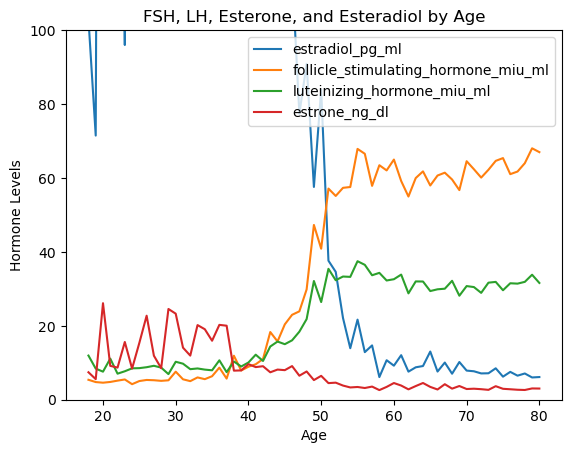

In [41]:
df_favg.plot(y=['estradiol_pg_ml','follicle_stimulating_hormone_miu_ml','luteinizing_hormone_miu_ml','estrone_ng_dl'])
plt.title('FSH, LH, Esterone, and Esteradiol by Age')
plt.xlabel('Age')
plt.ylabel('Hormone Levels')
plt.ylim(0,100)
plt.show()

Menopause is generally diagnosed clinically with symptoms, particularly lack of menstruation for 12 months. Serum hormone levels are not as accurate in diagnosing menopause but for the purposes of this analysis, the indicator used will be FSH >30 mIU/mL and estradiol <20 pg/mL (https://www.ncbi.nlm.nih.gov/books/NBK507826/), where one of these conditions is met. It appears that roughtly around age 45 the menopausal signs begin in this cohort. Women of age 18-45 will be considered premenopausal and women who are older than 45 will be considered postmenopausal in this analysis. 

In [43]:
df_females['menopause_status'] = df_females['age_year'].apply(lambda x: 'premenopausal' if x <= 45 else 'postmenopausal')

/var/folders/sb/8r1ll48x2md1p01_fzj423yh0000gn/T/ipykernel_6728/668224921.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_females['menopause_status'] = df_females['age_year'].apply(lambda x: 'premenopausal' if x <= 45 else 'postmenopausal')
